# KV 长度受控扫描: 多图累积 vs 纯文本填充

把 `experiments/scripts/run_kv_length_sweep.py` 提到 notebook 跑(用户偏好交互式)。脚本逻辑原样照搬:
trial 函数 / 计时口径 / cond 配置 / seed 公式全部保持与脚本一致,这样切回脚本跑也能对齐。

| 维度 | 取值 |
|------|------|
| placement | pipeline(13/15 accelerate,与 EDIT_THINK_RATIO.md 口径一致) |
| R / N | 1024 / 10 |
| cap | 1000(budget forcing, min=max=cap) |
| CFG | bench(cfg_text_scale = cfg_img_scale = 1.0,跳过 CFG 分支单次前向) |
| 模式 A | multi_image — 固定最终图+prompt,前置注入 n_prior_turns 轮参考图 |
| 模式 B | text_filler — 固定图+prompt,在编辑文本之后追加纯文本填充 |

实验动机 / 设计细节见原脚本 docstring;下面只放运行需要的代码。

**预计耗时**: 模型加载 ~70s + multi_image 18 trials ≈ 8min + text_filler 36 trials ≈ 15min,合计 ≈ **25 min**。
两个 sweep cell 都有断点续跑保护: 输出 CSV 已存在时自动跳过(`FORCE_RERUN=True` 强制重跑)。

## 1. 环境 / import

`CUDA_VISIBLE_DEVICES` 必须在 import torch 之前设置(`docs/DEBUG_NOTES.md §8.4`)。优先用 kernel.json env 注入;缺失则 setdefault 兜底,若本 kernel 已 import 过 torch 需 Restart Kernel。
trial / 计时 / seed 等全部复用 `experiments/scripts/run_kv_length_sweep.py`,避免代码分叉。

In [1]:
import os
import sys
import time
import gc

# ── CUDA_VISIBLE_DEVICES: 必须在 import torch 之前 (DEBUG_NOTES.md §8.4) ──
_pre_cvd = os.environ.get("CUDA_VISIBLE_DEVICES")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")
if _pre_cvd is None:
    print(f"⚠ CUDA_VISIBLE_DEVICES 未在 kernel 启动时注入, setdefault 兜底为 "
          f"{os.environ['CUDA_VISIBLE_DEVICES']} — 若本 kernel 已 import 过 torch 请 Restart Kernel")
else:
    print(f"CUDA_VISIBLE_DEVICES = {_pre_cvd} (kernel.json env 注入)")

# 允许从 repo root / experiments/ / experiments/notebooks/ 启动
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    _proj_root = os.path.abspath(os.path.join(_cwd, "..", ".."))
elif os.path.basename(_cwd) == "experiments":
    _proj_root = os.path.abspath(os.path.join(_cwd, ".."))
else:
    _proj_root = _cwd
if _proj_root not in sys.path:
    sys.path.insert(0, _proj_root)
os.chdir(_proj_root)
print(f"project root: {_proj_root}")

import numpy as np
import torch
import pandas as pd

print(f"torch {torch.__version__}, visible GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  cuda:{i} = {torch.cuda.get_device_name(i)}")
assert torch.cuda.device_count() >= 2, "KV 扫描沿用 pipeline 双卡加载, 需要 2 张 GPU 可见"

⚠ CUDA_VISIBLE_DEVICES 未在 kernel 启动时注入, setdefault 兜底为 0,1 — 若本 kernel 已 import 过 torch 请 Restart Kernel
project root: /home/wuwenxuan03/bagel
torch 2.5.1+cu121, visible GPUs: 2
  cuda:0 = NVIDIA GeForce RTX 4090
  cuda:1 = NVIDIA GeForce RTX 4090


## 2. 实验配置 + 复用脚本工具

全部常量 / 条件构造 / trial 函数 / 计时器都从 `run_kv_length_sweep` 直接 import — 脚本是单一事实源,notebook 只是交互入口。
两个 sweep 在同一 kernel 跑,共用一次模型加载。

In [2]:
from experiments.scripts.run_kv_length_sweep import (
    # 常量
    OUTPUT_DIR, MEM_DEVICES, CFG_BENCH,
    PRIOR_IMAGE_POOL, PRIOR_TURN_TEXT, FINAL_IMAGE_PATH, FINAL_PROMPT,
    DEFAULT_N_PRIOR_TURNS,
    FILLER_SENTENCE, TEXT_FILLER_TRIALS, DEFAULT_FILLERS,
    # 工具函数
    build_filler_text, build_cond,
    run_multi_image_trial, run_text_filler_trial,
    _linfit_summary, _print_linfit,
)
from experiments.scripts.run_asym_bench import (
    _load_model_pipeline, sync_timer, set_all_seeds, reset_taylorseer_state,
    MODEL_PATH, SEED_BASE, WARMUP_SEED,
)
from data.transforms import ImageTransform
from inferencer import InterleaveInferencer

# 实验参数
CAP = 1000
NUM_TIMESTEPS = 10
N_PRIOR_TURNS = DEFAULT_N_PRIOR_TURNS                # [0, 1, 2, 3, 4, 5]
FILLERS = DEFAULT_FILLERS                            # [0, 1000, 4000, 8000, 16000, 24000]
REPEATS = 3

COND = build_cond(CAP, NUM_TIMESTEPS)

MULTI_CSV = os.path.join(OUTPUT_DIR, "multi_image_sweep_trials.csv")
FILLER_CSV = os.path.join(OUTPUT_DIR, "text_filler_sweep_trials.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)

FORCE_RERUN = False
RUN_MULTI_IMAGE = FORCE_RERUN or not os.path.exists(MULTI_CSV)
RUN_TEXT_FILLER = FORCE_RERUN or not os.path.exists(FILLER_CSV)
print(f"cap={CAP} N={NUM_TIMESTEPS} repeats={REPEATS}")
print(f"  multi_image  : {len(N_PRIOR_TURNS)} pts × {REPEATS} reps = {len(N_PRIOR_TURNS)*REPEATS} trials")
print(f"  text_filler  : {len(TEXT_FILLER_TRIALS)} imgs × {len(FILLERS)} pts × {REPEATS} reps = "
      f"{len(TEXT_FILLER_TRIALS)*len(FILLERS)*REPEATS} trials")
print(f"RUN_MULTI_IMAGE={RUN_MULTI_IMAGE}, RUN_TEXT_FILLER={RUN_TEXT_FILLER} (FORCE_RERUN={FORCE_RERUN})")

cap=1000 N=10 repeats=3
  multi_image  : 6 pts × 3 reps = 18 trials
  text_filler  : 2 imgs × 6 pts × 3 reps = 36 trials
RUN_MULTI_IMAGE=True, RUN_TEXT_FILLER=True (FORCE_RERUN=False)


## 3. 加载 pipeline 模型

`_load_model_pipeline`(13/15 accelerate 加载)与 `run_kv_length_sweep.py` / `run_cap_sweep_mp.py` 口径一致。两个 sweep 共用这次加载,skip 时(CSV 已存在)整段跳过。

In [3]:
if RUN_MULTI_IMAGE or RUN_TEXT_FILLER:
    _t0 = time.perf_counter()
    model, vae_model, tokenizer, new_token_ids = _load_model_pipeline(MODEL_PATH)
    inferencer = InterleaveInferencer(
        model=model, vae_model=vae_model, tokenizer=tokenizer,
        vae_transform=ImageTransform(1024, 512, 16),
        vit_transform=ImageTransform(980, 224, 14),
        new_token_ids=new_token_ids,
    )
    print(f"[pipeline] ready in {time.perf_counter() - _t0:.0f}s")
else:
    print(f"跳过加载({MULTI_CSV} 和 {FILLER_CSV} 均已存在, FORCE_RERUN=False)")

The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.


[pipeline] device_map: GPU 0 = layers 0-12 + embed + aux(same-device), GPU 1 = layers 13-27 + norm/head/vit


  0%|          | 0/1223 [00:00<?, ?w/s]

We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.


[pipeline] ready in 81s


## 4. 实验 A: multi_image 扫描(18 trials, 预计 ~8 min)

固定最终编辑图(`test_images/women.jpg`)+ 编辑 prompt + cap=1000 + N=10,前置注入 `n_prior_turns` 轮参考图+短指令。KV 长度随图片 token 线性累积,贴近业务多轮场景。

In [4]:
if RUN_MULTI_IMAGE:
    print("[multi_image] warmup: n_prior_turns=0, cap=64 ...")
    w_cond = dict(COND, max_think_token_n=64, min_think_token_n=64)
    w = run_multi_image_trial(inferencer, tokenizer, 0, FINAL_IMAGE_PATH, FINAL_PROMPT,
                              w_cond, seed=WARMUP_SEED)
    assert w["ok"], f"[multi_image] warmup FAILED: {w['error']}"
    print(f"[multi_image] warmup ok: t_think={w['t_think']:.2f}s t_image={w['t_image']:.2f}s "
          f"kv_len={w['kv_len_prefill']}")

    rows, t0 = [], time.perf_counter()
    total = len(N_PRIOR_TURNS) * REPEATS
    i = 0
    for ni, n_prior in enumerate(N_PRIOR_TURNS):
        for repeat in range(REPEATS):
            i += 1
            seed = SEED_BASE + ni * 100 + repeat
            row = run_multi_image_trial(inferencer, tokenizer, n_prior, FINAL_IMAGE_PATH,
                                        FINAL_PROMPT, COND, seed)
            row["trial_idx"] = i
            rows.append(row)
            st = "ok" if row["ok"] else f"FAIL({str(row['error'])[:80]})"
            elapsed = time.perf_counter() - t0
            print(f"[multi_image] [{i}/{total}] n_prior_turns={n_prior} repeat={repeat}: {st} "
                  f"kv_len={row.get('kv_len_prefill')} t_think={row.get('t_think')} "
                  f"t_image={row.get('t_image')} tok/s={row.get('think_tok_per_sec')} "
                  f"elapsed={elapsed:.0f}s")

    df = pd.DataFrame(rows)
    df["hardware"] = torch.cuda.get_device_name(0)
    df["timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
    df.to_csv(MULTI_CSV, index=False)
    print(f"\n[multi_image] wrote {len(df)} rows → {MULTI_CSV}")
else:
    print(f"跳过 multi_image sweep({MULTI_CSV} 已存在, FORCE_RERUN=False)")

[multi_image] warmup: n_prior_turns=0, cap=64 ...


100%|██████████| 9/9 [00:04<00:00,  2.12it/s]


[multi_image] warmup ok: t_think=3.74s t_image=5.16s kv_len=7121


100%|██████████| 9/9 [00:04<00:00,  2.08it/s]


[multi_image] [1/18] n_prior_turns=0 repeat=0: ok kv_len=7121 t_think=55.644404359161854 t_image=4.569588989019394 tok/s=17.953287693617202 elapsed=62s


...

[multi_image] [16/18] n_prior_turns=5 repeat=0: ok kv_len=30794 t_think=56.87239231169224 t_image=6.4664019495248795 tok/s=17.565640540051948 elapsed=1044s


100%|██████████| 9/9 [00:06<00:00,  1.42it/s]


[multi_image] [17/18] n_prior_turns=5 repeat=1: ok kv_len=30794 t_think=56.95964153856039 t_image=6.568299748003483 tok/s=17.538733970502598 elapsed=1115s


100%|██████████| 9/9 [00:06<00:00,  1.46it/s]


[multi_image] [18/18] n_prior_turns=5 repeat=2: ok kv_len=30794 t_think=56.80643663555384 t_image=6.415815703570843 tok/s=17.58603530105511 elapsed=1185s

[multi_image] wrote 18 rows → /home/wuwenxuan03/bagel/experiments/outputs/kv_length_sweep_outputs/multi_image_sweep_trials.csv


## 5. 实验 B: text_filler 扫描(36 trials, 预计 ~15 min)

在 2 张测试图上各扫 6 个 filler token 量,隔离 KV 长度本身的影响(不混入图片 token 特殊性)。如果 multi_image 与 text_filler 结论一致 → 支持"通用 KV 压缩在此场景无收益"。

In [5]:
if RUN_TEXT_FILLER:
    print("[text_filler] warmup: filler=0, cap=64 ...")
    w_cond = dict(COND, max_think_token_n=64, min_think_token_n=64)
    img, prompt = TEXT_FILLER_TRIALS[0]
    w = run_text_filler_trial(inferencer, tokenizer, img, prompt, 0, w_cond, seed=WARMUP_SEED)
    assert w["ok"], f"[text_filler] warmup FAILED: {w['error']}"
    print(f"[text_filler] warmup ok: t_think={w['t_think']:.2f}s t_image={w['t_image']:.2f}s "
          f"kv_len={w['kv_len_prefill']}")

    rows, t0 = [], time.perf_counter()
    total = len(TEXT_FILLER_TRIALS) * len(FILLERS) * REPEATS
    i = 0
    for pi, (img, prompt) in enumerate(TEXT_FILLER_TRIALS):
        for fi, filler_n in enumerate(FILLERS):
            for repeat in range(REPEATS):
                i += 1
                seed = SEED_BASE + pi * 10000 + fi * 100 + repeat
                row = run_text_filler_trial(inferencer, tokenizer, img, prompt, filler_n, COND, seed)
                row["trial_idx"] = i
                rows.append(row)
                st = "ok" if row["ok"] else f"FAIL({str(row['error'])[:80]})"
                elapsed = time.perf_counter() - t0
                print(f"[text_filler] [{i}/{total}] {os.path.basename(img)} filler={filler_n} "
                      f"repeat={repeat}: {st} "
                      f"kv_len={row.get('kv_len_prefill')} t_think={row.get('t_think')} "
                      f"t_image={row.get('t_image')} tok/s={row.get('think_tok_per_sec')} "
                      f"elapsed={elapsed:.0f}s")

    df = pd.DataFrame(rows)
    df["hardware"] = torch.cuda.get_device_name(0)
    df["timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
    df.to_csv(FILLER_CSV, index=False)
    print(f"\n[text_filler] wrote {len(df)} rows → {FILLER_CSV}")
else:
    print(f"跳过 text_filler sweep({FILLER_CSV} 已存在, FORCE_RERUN=False)")

[text_filler] warmup: filler=0, cap=64 ...


100%|██████████| 9/9 [00:04<00:00,  2.09it/s]


[text_filler] warmup ok: t_think=3.55s t_image=4.56s kv_len=7121


100%|██████████| 9/9 [00:04<00:00,  1.98it/s]


[text_filler] [1/36] women.jpg filler=0 repeat=0: ok kv_len=7121 t_think=55.46574619412422 t_image=4.797163404524326 tok/s=18.011116203207763 elapsed=62s


...

[text_filler] [34/36] octupusy.jpg filler=24000 repeat=0: ok kv_len=25077 t_think=55.617539651691914 t_image=3.0857987627387047 tok/s=17.96195959505393 elapsed=2138s


100%|██████████| 9/9 [00:03<00:00,  2.80it/s]


[text_filler] [35/36] octupusy.jpg filler=24000 repeat=1: ok kv_len=25077 t_think=55.654248744249344 t_image=3.3398967534303665 tok/s=17.950112031711235 elapsed=2205s


100%|██████████| 9/9 [00:02<00:00,  3.11it/s]


[text_filler] [36/36] octupusy.jpg filler=24000 repeat=2: ok kv_len=25077 t_think=55.583482682704926 t_image=3.0067596435546875 tok/s=17.95497424472347 elapsed=2270s

[text_filler] wrote 36 rows → /home/wuwenxuan03/bagel/experiments/outputs/kv_length_sweep_outputs/text_filler_sweep_trials.csv


## 6. 汇总: 每扫描点均值 + think_tok_per_sec ~ kv_len_prefill 线性拟合

汇总与脚本 `main()` 末尾的 groupby + `_print_linfit` 一致;拟合 slope × kv_len span / mean 用于判定"KV 长度是否有可见敏感性"(>5% 视为有)。

In [6]:
for csv_path, mode, group_cols in [
    (MULTI_CSV, "multi_image", ["n_prior_turns"]),
    (FILLER_CSV, "text_filler", ["image", "filler_token_n"]),
]:
    if not os.path.exists(csv_path):
        print(f"[skip] {csv_path} not found")
        continue
    df = pd.read_csv(csv_path)
    ok = df[df["ok"] == True]
    print(f"\n=== summary ({mode}): {len(df)} trials, {len(ok)} ok, {len(df)-len(ok)} failed ===")
    if len(df) - len(ok):
        print(df[df["ok"] != True][[*group_cols, "seed", "error"]].to_string())
    if not len(ok):
        continue
    grp = ok.groupby(group_cols).agg(
        kv_len_mean=("kv_len_prefill", "mean"),
        t_think_mean=("t_think", "mean"),
        tok_per_sec_mean=("think_tok_per_sec", "mean"),
        t_image_mean=("t_image", "mean"),
        mem_g0=("mem_alloc_gpu0", "mean"),
        mem_g1=("mem_alloc_gpu1", "mean"),
        n=("t_think", "count"),
    )
    print(grp.round(3).to_string())
    _print_linfit(ok)


=== summary (multi_image): 18 trials, 18 ok, 0 failed ===
               kv_len_mean  t_think_mean  tok_per_sec_mean  t_image_mean        mem_g0        mem_g1  n
n_prior_turns                                                                                          
0                   7121.0        55.247            18.083         4.577  1.756135e+10  1.687394e+10  3
1                  14186.0        55.331            18.055         5.164  1.793799e+10  1.731997e+10  3
2                  17390.0        55.285            18.070         5.383  1.810906e+10  1.762275e+10  3
3                  20525.0        55.814            17.899         5.675  1.827783e+10  1.794704e+10  3
4                  27590.0        56.482            17.687         6.191  1.865231e+10  1.858548e+10  3
5                  30794.0        56.879            17.563         6.484  1.883090e+10  1.891444e+10  3

think_tok_per_sec ~ kv_len_prefill: slope=-0.000024 intercept=18.356 R²=0.803
|slope|×span / mean = 3.1% (无实

## 7. 可视化

两张图(只依赖两份 trial CSV,可独立于模型环境重跑):

1. `kv_sweep_tokps_vs_kvlen.png` — think tok/s vs kv_len_prefill,两种模式叠加 + 线性拟合参考线
2. `kv_sweep_mem_vs_kvlen.png` — 每 GPU 峰值显存 vs kv_len_prefill

PNG 输出到 `OUTPUT_DIR`,按需在 `experiments/.gitignore` 加白名单入库。

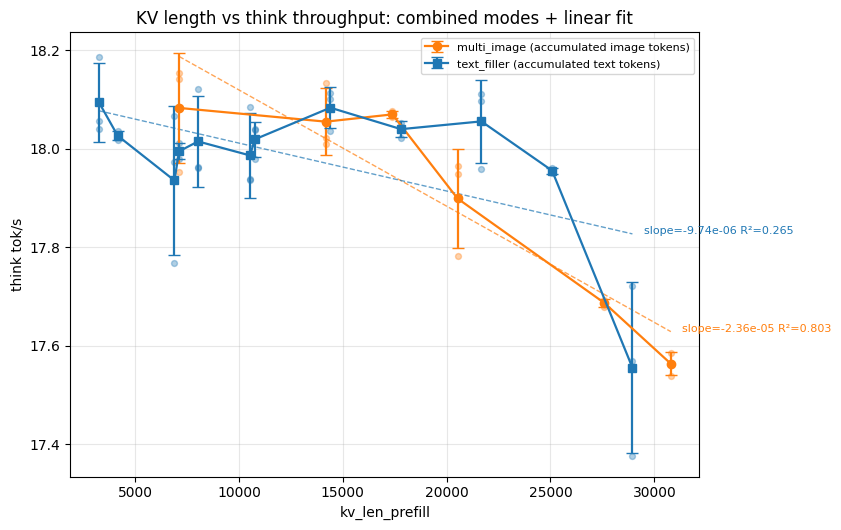

In [9]:
import matplotlib.pyplot as plt

STYLE = {
    "multi_image": dict(color="tab:orange", marker="o",
                         label="multi_image (accumulated image tokens)"),
    "text_filler": dict(color="tab:blue", marker="s",
                        label="text_filler (accumulated text tokens)"),
}


def _load_ok(csv_path, mode):
    if not os.path.exists(csv_path):
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    df["mode"] = mode
    return df[df["ok"] == True]


df_multi = _load_ok(MULTI_CSV, "multi_image")
df_filler = _load_ok(FILLER_CSV, "text_filler")
df = pd.concat([df_multi, df_filler], ignore_index=True)
if df.empty:
    print("no data to plot")
else:
    # ── 图 1: think tok/s vs kv_len_prefill ──
    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    for mode, st in STYLE.items():
        sub = df[df["mode"] == mode]
        if sub.empty:
            continue
        ax.scatter(sub["kv_len_prefill"], sub["think_tok_per_sec"],
                   s=18, alpha=0.35, color=st["color"], zorder=2)
        # 扫描点均值 + 拟合线
        m = sub.groupby("kv_len_prefill")["think_tok_per_sec"].agg(["mean", "std"]).sort_index()
        ax.errorbar(m.index, m["mean"], yerr=m["std"], marker=st["marker"], capsize=4,
                    color=st["color"], linewidth=1.6, zorder=3, label=st["label"])
        fit = _linfit_summary(sub, "kv_len_prefill", "think_tok_per_sec")
        if fit:
            slope, intercept, r2 = fit
            xs = np.linspace(sub["kv_len_prefill"].min(), sub["kv_len_prefill"].max(), 50)
            ax.plot(xs, slope * xs + intercept, "--", color=st["color"], linewidth=1, alpha=0.7)
            ax.annotate(f"slope={slope:.2e} R²={r2:.3f}",
                        xy=(xs[-1], slope * xs[-1] + intercept),
                        textcoords="offset points", xytext=(8, 0),
                        color=st["color"], fontsize=8)
    ax.set_xlabel("kv_len_prefill")
    ax.set_ylabel("think tok/s")
    ax.set_title("KV length vs think throughput: combined modes + linear fit")
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "kv_sweep_tokps_vs_kvlen.png"), dpi=150)
    plt.show()

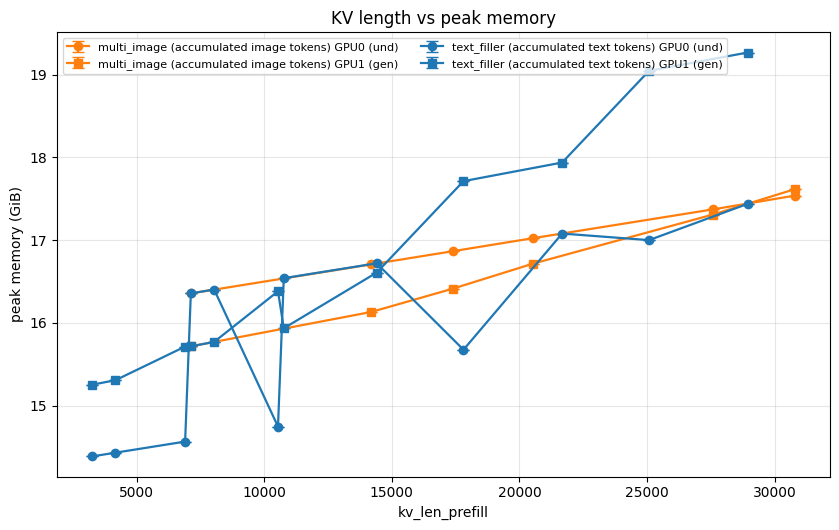

figures → /home/wuwenxuan03/bagel/experiments/outputs/kv_length_sweep_outputs


In [11]:
if df.empty:
    print("no data to plot")
else:
    # ── 图 2: 峰值显存 vs kv_len_prefill ──
    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    for mode, st in STYLE.items():
        sub = df[df["mode"] == mode]
        if sub.empty:
            continue
        for col, mk, lb in [("mem_alloc_gpu0", "o", "GPU0 (und)"),
                           ("mem_alloc_gpu1", "s", "GPU1 (gen)")]:
            if col not in sub.columns:
                continue
            ax.scatter(sub["kv_len_prefill"], sub[col] / 1024**3,
                       s=14, alpha=0.35, marker=mk, color=st["color"], zorder=2)
            m = sub.groupby("kv_len_prefill")[col].agg(["mean", "std"]).sort_index()
            ax.errorbar(m.index, m["mean"] / 1024**3, yerr=m["std"] / 1024**3,
                        marker=mk, capsize=4, color=st["color"], linewidth=1.6,
                        zorder=3,
                        label=f"{st['label']} {lb}")
    ax.set_xlabel("kv_len_prefill")
    ax.set_ylabel("peak memory (GiB)")
    ax.set_title("KV length vs peak memory")
    ax.legend(fontsize=8, loc="best", ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "kv_sweep_mem_vs_kvlen.png"), dpi=150)
    plt.show()

    print(f"figures → {OUTPUT_DIR}")

## 8. 结论

请在运行结束后填入:

- [ ] multi_image 扫描: kv_len_prefill 范围、t_think 区间、think tok/s 区间
- [ ] text_filler 扫描: 同上
- [ ] 两种模式拟合 slope × span / mean 是否 < 5%(无敏感) / ≥ 5%(有可见敏感)
- [ ] 是否支持"通用 KV 压缩方法在此场景无收益"这个论断

数字已与 `experiments/outputs/kv_length_sweep_outputs/{multi_image,text_filler}_sweep_trials.csv` 原始数据一致。